# F1 Podium Prediction: Milestone 1

## Section 1: Data cleaning and EDA

### 1.1 Load the data

We load all 14 tables into a dictionary called `raw`. The CSV files are never changed: we clean copies later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = '/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020'
TABLES = ['circuits', 'constructors', 'constructor_results', 'constructor_standings', 'drivers',
          'driver_standings', 'races', 'results', 'qualifying', 'lap_times', 'pit_stops',
          'sprint_results', 'seasons', 'status']

raw = {}
for t in TABLES:
    raw[t] = pd.read_csv(f'{DATA_DIR}/{t}.csv')

for t in TABLES:
    print(t, raw[t].shape)

circuits (77, 9)
constructors (212, 5)
constructor_results (12625, 5)
constructor_standings (13391, 7)
drivers (861, 9)
driver_standings (34863, 7)
races (1125, 18)
results (26759, 18)
qualifying (10494, 9)
lap_times (589081, 6)
pit_stops (11371, 7)
sprint_results (360, 16)
seasons (75, 2)
status (139, 2)


### 1.2 EDA before cleaning: missing values

This dataset does not leave missing cells empty. It writes the text `\N` instead, so pandas does not see them as missing.
We count the `\N` values in every table.

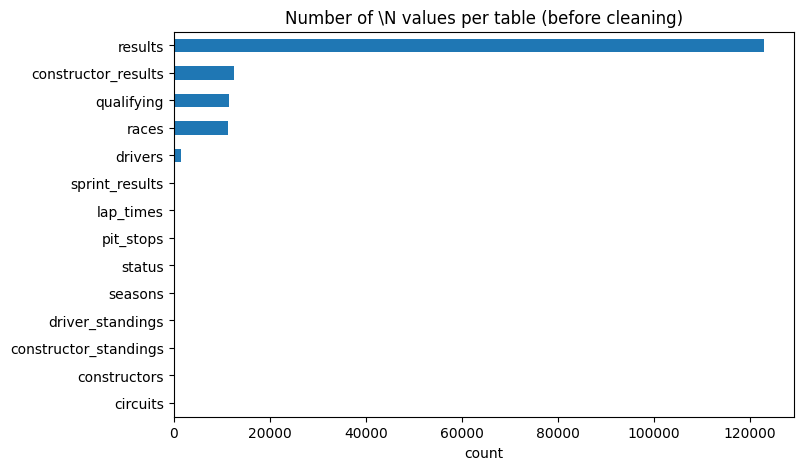

In [2]:
missing_before = {}
for t in TABLES:
    missing_before[t] = (raw[t] == '\\N').sum().sum()

pd.Series(missing_before).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Number of \\N values per table (before cleaning)')
plt.xlabel('count')
plt.show()

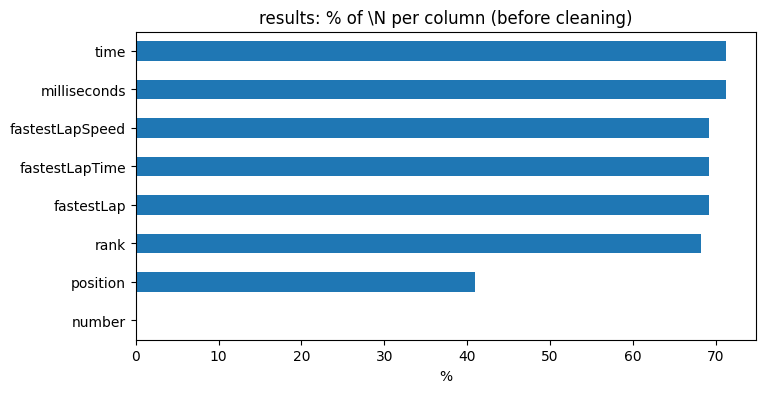

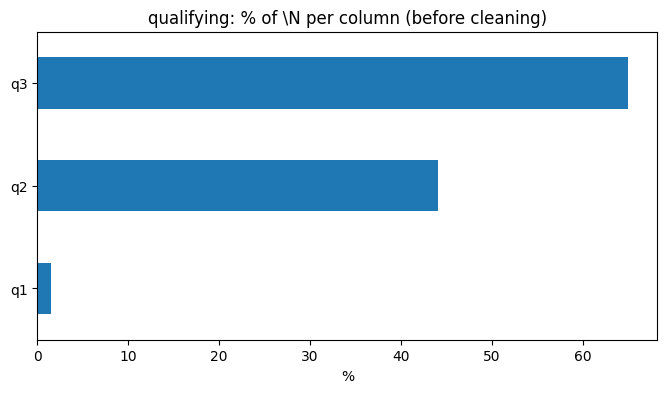

In [3]:
# Which columns of the two most important tables have missing values?
for t in ['results', 'qualifying']:
    pct = (raw[t] == '\\N').mean() * 100
    pct[pct > 0].sort_values().plot(kind='barh', figsize=(8, 4))
    plt.title(f'{t}: % of \\N per column (before cleaning)')
    plt.xlabel('%')
    plt.show()

### 1.3 Clean the missing values and fix the types

1. Replace every `\N` with `NaN`, the real "missing" value in pandas.
2. Turn a column into numbers if all its values are numbers. Columns like this were stored as text only because of the `\N`.
3. Turn date columns into real dates.
4. Turn qualifying lap times like `1:23.456` into seconds (83.456), so they can be compared and used as features.

In [4]:
def to_numbers(df):
    for col in df.columns:
        converted = pd.to_numeric(df[col], errors='coerce')
        if converted.notna().sum() == df[col].notna().sum():   # every value was a number
            df[col] = converted
    return df

def lap_time_to_seconds(text):
    if pd.isna(text):
        return np.nan
    minutes, seconds = text.split(':')
    return float(minutes) * 60 + float(seconds)

clean = {}
for t in TABLES:
    clean[t] = to_numbers(raw[t].replace('\\N', np.nan))

clean['races']['date'] = pd.to_datetime(clean['races']['date'])
clean['drivers']['dob'] = pd.to_datetime(clean['drivers']['dob'])
for col in ['q1', 'q2', 'q3']:
    clean['qualifying'][col] = clean['qualifying'][col].map(lap_time_to_seconds)

clean['qualifying'][['q1', 'q2', 'q3']].describe()

,q1,q2,q3
count,10338.000000,5847.000000,3629.000000
mean,88.531251,87.770120,87.405623
std,15.392958,12.110624,12.260018
min,53.904000,53.647000,53.377000
25%,78.773500,77.942000,77.238000
50%,87.141000,87.125000,87.039000
75%,95.909500,95.956000,95.626000
max,1002.640000,132.470000,129.776000


### 1.4 Check the keys

* **Primary key:** the column that identifies each row. It must be unique and never missing.
* **Foreign key:** a column that points to a row in another table (for example `results.driverId` points to `drivers`).
  Every value must exist in that other table, otherwise joins lose rows.

In [5]:
primary_keys = {
    'circuits': 'circuitId', 'constructors': 'constructorId', 'drivers': 'driverId', 'races': 'raceId',
    'results': 'resultId', 'qualifying': 'qualifyId', 'status': 'statusId', 'seasons': 'year',
    'constructor_results': 'constructorResultsId', 'constructor_standings': 'constructorStandingsId',
    'driver_standings': 'driverStandingsId', 'sprint_results': 'resultId',
}
for t, key in primary_keys.items():
    unique = clean[t][key].is_unique
    no_missing = clean[t][key].notna().all()
    print(f'{t}.{key}: unique={unique}, no missing={no_missing}')

circuits.circuitId: unique=True, no missing=True
constructors.constructorId: unique=True, no missing=True
drivers.driverId: unique=True, no missing=True
races.raceId: unique=True, no missing=True
results.resultId: unique=True, no missing=True
qualifying.qualifyId: unique=True, no missing=True
status.statusId: unique=True, no missing=True
seasons.year: unique=True, no missing=True
constructor_results.constructorResultsId: unique=True, no missing=True
constructor_standings.constructorStandingsId: unique=True, no missing=True
driver_standings.driverStandingsId: unique=True, no missing=True
sprint_results.resultId: unique=True, no missing=True


In [6]:
foreign_keys = [  # (table, column, table it points to, key there)
    ('races', 'circuitId', 'circuits', 'circuitId'),
    ('results', 'raceId', 'races', 'raceId'),
    ('results', 'driverId', 'drivers', 'driverId'),
    ('results', 'constructorId', 'constructors', 'constructorId'),
    ('results', 'statusId', 'status', 'statusId'),
    ('qualifying', 'raceId', 'races', 'raceId'),
    ('qualifying', 'driverId', 'drivers', 'driverId'),
    ('driver_standings', 'raceId', 'races', 'raceId'),
    ('driver_standings', 'driverId', 'drivers', 'driverId'),
    ('constructor_standings', 'constructorId', 'constructors', 'constructorId'),
]
for table, col, parent, parent_key in foreign_keys:
    missing = ~clean[table][col].isin(clean[parent][parent_key])
    print(f'{table}.{col} -> {parent}: {missing.sum()} values not found')

races.circuitId -> circuits: 0 values not found
results.raceId -> races: 0 values not found
results.driverId -> drivers: 0 values not found
results.constructorId -> constructors: 0 values not found
results.statusId -> status: 0 values not found
qualifying.raceId -> races: 0 values not found
qualifying.driverId -> drivers: 0 values not found
driver_standings.raceId -> races: 0 values not found
driver_standings.driverId -> drivers: 0 values not found
constructor_standings.constructorId -> constructors: 0 values not found


### 1.5 One row per driver per race

Each row of our model is one prediction: "will this driver finish on the podium in this race?"
So a driver can only appear once per race. In the 1950s, drivers sometimes drove two cars in the same race
(shared drives), which gives them two rows.

In [7]:
results = clean['results']
dup = results[results.duplicated(['raceId', 'driverId'], keep=False)]
print('Rows that are duplicates:', len(dup))
print('Years:', sorted(dup.merge(clean['races'], on='raceId')['year'].unique().tolist()))
dup[['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder']]

Rows that are duplicates: 176
Years: [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1960, 1961, 1962, 1964, 1978]


,raceId,driverId,constructorId,grid,positionOrder
13188,540,229,54,0,26
13191,540,229,57,0,29
17362,717,373,172,1,7
17740,733,465,172,0,22
17743,733,465,97,0,25
...,...,...,...,...,...
20293,770,479,118,10,14
20294,774,566,105,11,4
20295,746,475,170,8,3
24297,745,418,172,15,11


**Our rule: keep the row of the car the driver started the race in** (the row with a grid position above 0).
If more than one row qualifies, we keep the first one listed.

Why: our features (grid, qualifying) must describe the car the driver actually started in, because that is what is
known before the race. Choosing the row with the best finishing position instead would use the race result, which is
not known before the race.

In [8]:
results = results.assign(no_start=(results['grid'] == 0))
results = results.sort_values(['no_start', 'resultId'])
results = results.drop_duplicates(['raceId', 'driverId'])
clean['results'] = results.drop(columns='no_start').sort_values('resultId')

print('Rows before:', len(raw['results']), '| rows after:', len(clean['results']))
print('Duplicates left:', clean['results'].duplicated(['raceId', 'driverId']).sum())

Rows before: 26759 | rows after: 26668
Duplicates left: 0


### 1.6 EDA after cleaning

We add `podium` (finished 1st, 2nd or 3rd) only to explore the data here.

In [13]:
data = clean['results'].merge(clean['races'][['raceId', 'year']], on='raceId')
data['podium'] = data['positionOrder'] <= 3

summary = pd.DataFrame({
    'rows before': [len(raw[t]) for t in TABLES],
    'rows after': [len(clean[t]) for t in TABLES],
    '\\N before': [missing_before[t] for t in TABLES],
    'NaN after': [clean[t].isna().sum().sum() for t in TABLES],
    'number columns before': [raw[t].select_dtypes('number').shape[1] for t in TABLES],
    'number columns after': [clean[t].select_dtypes('number').shape[1] for t in TABLES],
}, index=TABLES)
summary

,rows before,rows after,\N before,NaN after,number columns before,number columns after
circuits,77,77,0,0,4,4
constructors,212,212,0,0,1,1
constructor_results,12625,12625,12608,12608,4,4
constructor_standings,13391,13391,0,0,6,6
drivers,861,861,1559,1559,1,2
driver_standings,34863,34863,0,0,6,6
races,1125,1125,11349,11349,4,4
results,26759,26668,122887,122339,9,15
qualifying,10494,10494,11600,11668,6,9
lap_times,589081,589081,0,0,5,5


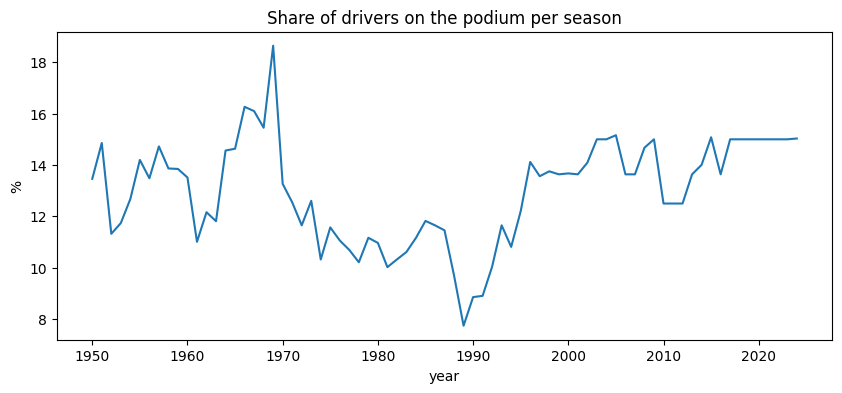

Overall: 12.7% of rows are podiums, so the classes are unbalanced.


In [10]:
(data.groupby('year')['podium'].mean() * 100).plot(figsize=(10, 4))
plt.title('Share of drivers on the podium per season')
plt.ylabel('%')
plt.show()
print(f'Overall: {data["podium"].mean():.1%} of rows are podiums, so the classes are unbalanced.')

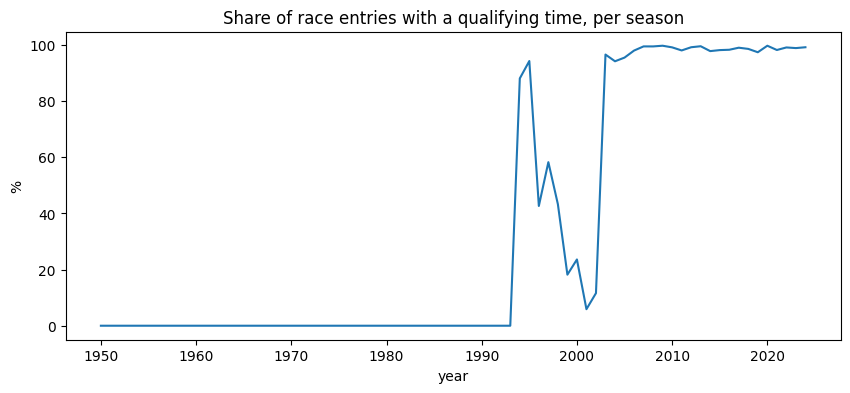

In [11]:
has_quali = data.merge(clean['qualifying'][['raceId', 'driverId', 'q1']], on=['raceId', 'driverId'], how='left')
(has_quali.groupby('year')['q1'].apply(lambda s: s.notna().mean()) * 100).plot(figsize=(10, 4))
plt.title('Share of race entries with a qualifying time, per season')
plt.ylabel('%')
plt.show()

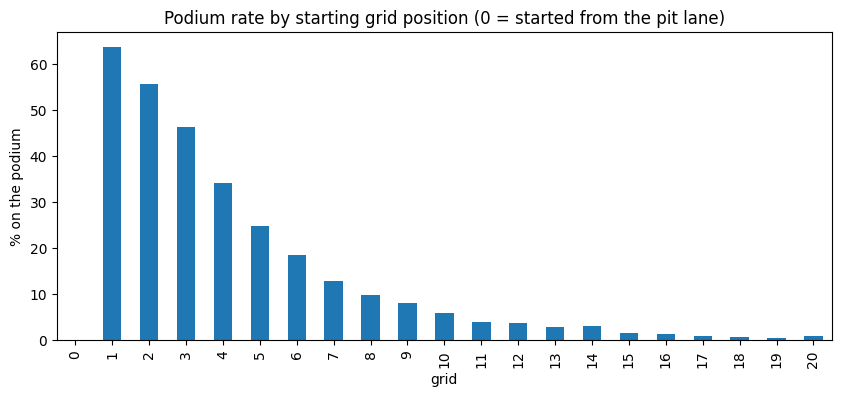

In [12]:
(data[data['grid'] <= 20].groupby('grid')['podium'].mean() * 100).plot(kind='bar', figsize=(10, 4))
plt.title('Podium rate by starting grid position (0 = started from the pit lane)')
plt.ylabel('% on the podium')
plt.show()